In [1]:
from __future__ import annotations

import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.feature_sets import BASE_TABULAR_FEATURES, GCMT_FEATURES, QUALITY_FEATURES
from src.models.input_layer import load_modeling_splits

DATASET_NAME = "earthquake_aftershock_v2_gcmt"
HORIZONS = ["24h", "72h"]
OUTPUT_DIR = PROJECT_ROOT / "reports" / "metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch version: {torch.__version__}")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available. Notebook will still run on CPU.")

Torch version: 2.11.0+cpu
Using device: cpu
CUDA not available. Notebook will still run on CPU.


In [2]:
splits = load_modeling_splits(dataset_name=DATASET_NAME)

def engineer_features(df):
    df = df.copy()
    has_gcmt = (
        df["has_gcmt"].fillna(False)
        if "has_gcmt" in df.columns
        else pd.Series(False, index=df.index)
    )
    df["depth_shallow"]      = (df["trigger_depth_km"] < 70).astype(float)
    df["depth_intermediate"] = df["trigger_depth_km"].between(70, 300).astype(float)
    df["depth_deep"]         = (df["trigger_depth_km"] > 300).astype(float)
    df["log_magnitude"]      = np.log10(df["trigger_magnitude"].clip(lower=1e-6))
    df["mag_depth_ratio"]    = df["trigger_magnitude"] / (df["trigger_depth_km"] + 1)
    df["log_scalar_moment"]  = np.where(
        has_gcmt & df["gcmt_scalar_moment"].notna(),
        np.log10(df["gcmt_scalar_moment"].clip(lower=1e-10)), np.nan,
    )
    df["sin_month"]     = np.sin(2 * np.pi * df["trigger_month"]     / 12)
    df["cos_month"]     = np.cos(2 * np.pi * df["trigger_month"]     / 12)
    df["sin_hour"]      = np.sin(2 * np.pi * df["trigger_hour"]      / 24)
    df["cos_hour"]      = np.cos(2 * np.pi * df["trigger_hour"]      / 24)
    df["sin_dayofyear"] = np.sin(2 * np.pi * df["trigger_dayofyear"] / 365)
    df["cos_dayofyear"] = np.cos(2 * np.pi * df["trigger_dayofyear"] / 365)
    df["ring_of_fire"]  = (
        (np.abs(df["trigger_longitude"]) > 130)
        & df["trigger_latitude"].between(-60, 60)
    ).astype(float)
    def _rake_regimes(rake):
        if pd.isna(rake): return np.nan, np.nan, np.nan
        r = rake % 360
        ss = min(abs(r), abs(r - 180), abs(r - 360))
        return float(ss < 45), float(45 <= r <= 135), float(225 <= r <= 315)
    regimes = df["rake"].apply(
        lambda r: _rake_regimes(r) if pd.notna(r) else (np.nan, np.nan, np.nan)
    )
    df["is_strike_slip"] = regimes.apply(lambda x: x[0]).where(has_gcmt)
    df["is_reverse"]     = regimes.apply(lambda x: x[1]).where(has_gcmt)
    df["is_normal"]      = regimes.apply(lambda x: x[2]).where(has_gcmt)
    df["sin_dip"]        = np.sin(np.radians(df["dip"].where(has_gcmt)))
    e1 = df["gcmt_eig1"].where(has_gcmt)
    e2 = df["gcmt_eig2"].where(has_gcmt)
    e3 = df["gcmt_eig3"].where(has_gcmt)
    denom = (e1.abs() + e3.abs()).replace(0, np.nan)
    df["clvd_fraction"]            = (2 * e2.abs() / denom).where(has_gcmt)
    df["centroid_depth_diff"]      = (df["gcmt_depth_km"] - df["trigger_depth_km"]).where(has_gcmt)
    df["log_half_duration"]        = np.log1p(df["gcmt_half_duration_sec"].where(has_gcmt))
    df["mag_diff_abs"]             = df["gcmt_mag_diff"].abs().where(has_gcmt)
    df["moment_exponent_centered"] = (df["gcmt_moment_exponent"].where(has_gcmt) - 24.0)
    prior_24h = df["prior_global_event_count_24h"]
    prior_7d  = df["prior_global_event_count_7d"]
    df["log_prior_24h"]           = np.log1p(prior_24h)
    df["log_prior_7d"]            = np.log1p(prior_7d)
    df["seismicity_acceleration"] = prior_24h / (prior_7d / 7.0).replace(0, np.nan)
    df["mag_x_shallow"]           = df["trigger_magnitude"] * df["depth_shallow"]
    df["mag_x_log_prior"]         = df["trigger_magnitude"] * np.log1p(prior_24h)
    return df

ENGINEERED_FEATURES = [
    "depth_shallow","depth_intermediate","depth_deep",
    "log_magnitude","mag_depth_ratio","log_scalar_moment",
    "sin_month","cos_month","sin_hour","cos_hour","sin_dayofyear","cos_dayofyear",
    "ring_of_fire","is_strike_slip","is_reverse","is_normal",
    "sin_dip","clvd_fraction","centroid_depth_diff","log_half_duration","mag_diff_abs",
    "moment_exponent_centered",
    "log_prior_24h","log_prior_7d","seismicity_acceleration",
    "mag_x_shallow","mag_x_log_prior",
]

_seen = set()
FULL_FEATURE_SET = []
for f in BASE_TABULAR_FEATURES + QUALITY_FEATURES + GCMT_FEATURES + ENGINEERED_FEATURES:
    if f not in _seen:
        FULL_FEATURE_SET.append(f)
        _seen.add(f)

splits_eng = {name: engineer_features(df) for name, df in splits.items()}
train_df = splits_eng["train"].copy()
val_df   = splits_eng["val"].copy()
test_df  = splits_eng["test"].copy()

print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")
print(f"Total features: {len(FULL_FEATURE_SET)}")

Train: 23,031 rows
Val:   1,744 rows
Test:  3,513 rows
Total features: 83


In [3]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, model_name: str, horizon: str, split: str) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "model_name": model_name,
        "horizon": horizon,
        "split": split,
        "MAE": round(float(mae), 4),
        "RMSE": round(float(rmse), 4),
    }


def build_predictions_df(trigger_ids: np.ndarray, split: str, horizon: str, model_name: str, y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame({
        "trigger_event_id": trigger_ids,
        "split": split,
        "horizon": horizon,
        "model_name": model_name,
        "y_true": y_true,
        "y_pred": y_pred,
    })


class TwoHeadNet(nn.Module):
    def __init__(self, n_features: int, hidden_dim: int = 256, dropout: float = 0.25):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.SiLU(),
            nn.Dropout(dropout),
        )
        self.cls_head = nn.Linear(hidden_dim // 2, 1)
        self.reg_head = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.backbone(x)
        logit_nonzero = self.cls_head(h).squeeze(-1)
        # Ensure non-negative log1p(count) predictions for numerical stability.
        log_count = F.softplus(self.reg_head(h).squeeze(-1))
        return logit_nonzero, log_count


def prepare_arrays(df: pd.DataFrame, feature_cols: list[str], target_col: str) -> tuple[pd.DataFrame, pd.Series]:
    keep_cols = feature_cols + [target_col, "trigger_event_id"]
    out = df[keep_cols].copy()
    out = out.dropna(subset=[target_col])
    X = out[feature_cols]
    y = out[target_col].astype(float)
    return out, X, y

In [4]:
FEATURE_COLS = FULL_FEATURE_SET

DEFAULT_CFG = {
    "batch_size": 256,
    "epochs": 90,
    "lr": 8e-4,
    "weight_decay": 1e-4,
    "patience": 16,
    "lambda_cls": 1.0,
    "lambda_reg": 1.0,
    "hidden_dim": 192,
    "dropout": 0.22,
    "clip_grad": 1.0,
}

# Updated after expanded-dataset retune.
HORIZON_CONFIGS = {
    "24h": {
        "batch_size": 256,
        "epochs": 90,
        "lr": 8e-4,
        "weight_decay": 8e-5,
        "patience": 16,
        "lambda_cls": 1.0,
        "lambda_reg": 1.1,
        "hidden_dim": 192,
        "dropout": 0.18,
        "clip_grad": 1.0,
    },
    "72h": {
        "batch_size": 192,
        "epochs": 110,
        "lr": 5e-4,
        "weight_decay": 1.5e-4,
        "patience": 20,
        "lambda_cls": 0.95,
        "lambda_reg": 1.2,
        "hidden_dim": 256,
        "dropout": 0.25,
        "clip_grad": 1.0,
    },
}

LOG1P_FEATURES = [
    "prior_global_event_count_24h",
    "prior_global_event_count_7d",
]

WINSORIZE_CANDIDATES = [
    "prior_global_event_count_24h",
    "prior_global_event_count_7d",
    "gcmt_distance_km",
    "gcmt_time_diff_sec",
    "trigger_depth_km",
    "gcmt_depth_km",
]

# Best cleaning after 83-feature retune: all_cleaning for 24h, missing_flags_only for 72h.
HORIZON_CLEANING_SETUP = {
    "24h": {"use_missing_flags": True, "use_log1p": True, "use_winsor": True},
    "72h": {"use_missing_flags": False, "use_log1p": True, "use_winsor": False},
}

TARGET_CAPS = {
    "24h": 300.0,
    "72h": 500.0,
}

all_metrics = []
all_predictions = []
training_history = {}

for horizon in HORIZONS:
    cfg = {**DEFAULT_CFG, **HORIZON_CONFIGS.get(horizon, {})}
    clean_cfg = HORIZON_CLEANING_SETUP.get(
        horizon,
        {"use_missing_flags": False, "use_log1p": False, "use_winsor": False},
    )
    target_col = f"n_aftershocks_{horizon}"
    print(f"\n{'='*70}")
    print(f"Horizon: {horizon} | Target: {target_col}")
    print(
        f"Config: batch_size={cfg['batch_size']}, epochs={cfg['epochs']}, lr={cfg['lr']}, "
        f"wd={cfg['weight_decay']}, hidden={cfg['hidden_dim']}, dropout={cfg['dropout']}"
    )
    print(
        f"Cleaning: missing_flags={clean_cfg['use_missing_flags']}, "
        f"log1p={clean_cfg['use_log1p']}, winsor={clean_cfg['use_winsor']}"
    )
    print(f"{'='*70}")

    train_keep, X_train_df, y_train_s = prepare_arrays(train_df, FEATURE_COLS, target_col)
    val_keep, X_val_df, y_val_s = prepare_arrays(val_df, FEATURE_COLS, target_col)
    test_keep, X_test_df, y_test_s = prepare_arrays(test_df, FEATURE_COLS, target_col)

    X_train_df = X_train_df.copy()
    X_val_df = X_val_df.copy()
    X_test_df = X_test_df.copy()
    feature_cols = FEATURE_COLS.copy()

    if clean_cfg["use_missing_flags"]:
        # Add explicit missingness indicators for GCMT columns with meaningful missing rates.
        missing_flag_cols = []
        for col in GCMT_FEATURES:
            if col in X_train_df.columns and X_train_df[col].isna().mean() > 0.05:
                flag_col = f"{col}__is_missing"
                X_train_df[flag_col] = X_train_df[col].isna().astype(np.float32)
                X_val_df[flag_col] = X_val_df[col].isna().astype(np.float32)
                X_test_df[flag_col] = X_test_df[col].isna().astype(np.float32)
                missing_flag_cols.append(flag_col)
        feature_cols.extend(missing_flag_cols)

    if clean_cfg["use_log1p"]:
        # Stabilize heavy-tailed count-like inputs.
        for col in LOG1P_FEATURES:
            if col in X_train_df.columns:
                X_train_df[col] = np.log1p(X_train_df[col].clip(lower=0))
                X_val_df[col] = np.log1p(X_val_df[col].clip(lower=0))
                X_test_df[col] = np.log1p(X_test_df[col].clip(lower=0))

    if clean_cfg["use_winsor"]:
        # Robust clipping based on train quantiles to reduce outlier leverage.
        for col in WINSORIZE_CANDIDATES:
            if col in X_train_df.columns:
                lo = float(X_train_df[col].quantile(0.005))
                hi = float(X_train_df[col].quantile(0.995))
                if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
                    X_train_df[col] = X_train_df[col].clip(lower=lo, upper=hi)
                    X_val_df[col] = X_val_df[col].clip(lower=lo, upper=hi)
                    X_test_df[col] = X_test_df[col].clip(lower=lo, upper=hi)

    # Train-only preprocessing
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train = scaler.fit_transform(imputer.fit_transform(X_train_df[feature_cols])).astype(np.float32)
    X_val = scaler.transform(imputer.transform(X_val_df[feature_cols])).astype(np.float32)
    X_test = scaler.transform(imputer.transform(X_test_df[feature_cols])).astype(np.float32)

    y_train = y_train_s.to_numpy(dtype=np.float32)
    y_val = y_val_s.to_numpy(dtype=np.float32)
    y_test = y_test_s.to_numpy(dtype=np.float32)

    target_cap = TARGET_CAPS.get(horizon)
    if target_cap is not None:
        # Cap evaluation targets only to match teammate setup.
        y_val = np.clip(y_val, 0.0, target_cap)
        print(f"Applied val-only cap for {horizon}: {target_cap:.0f}")

    y_train_nonzero = (y_train > 0).astype(np.float32)
    y_val_nonzero = (y_val > 0).astype(np.float32)

    # Regression target is log1p(count)
    y_train_log = np.log1p(y_train).astype(np.float32)
    y_val_log = np.log1p(y_val).astype(np.float32)

    train_ds = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train_nonzero),
        torch.from_numpy(y_train_log),
        torch.from_numpy(y_train),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val),
        torch.from_numpy(y_val_nonzero),
        torch.from_numpy(y_val_log),
        torch.from_numpy(y_val),
    )

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False)

    model = TwoHeadNet(
        n_features=X_train.shape[1],
        hidden_dim=cfg["hidden_dim"],
        dropout=cfg["dropout"],
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
    )

    # Counter class imbalance in non-zero head.
    n_pos = max(1.0, float(y_train_nonzero.sum()))
    n_neg = max(1.0, float(len(y_train_nonzero) - y_train_nonzero.sum()))
    pos_weight = torch.tensor([n_neg / n_pos], device=device, dtype=torch.float32)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    reg_loss_fn = nn.SmoothL1Loss(beta=0.35)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        threshold=1e-4,
        min_lr=1e-6,
    )

    best_state = None
    best_val_mae = float("inf")
    patience_ctr = 0
    history_rows = []

    def predict_expected_count(X_np: np.ndarray) -> np.ndarray:
        xb = torch.from_numpy(X_np).to(device)
        with torch.no_grad():
            logit_nonzero, log_count = model(xb)
            p_nonzero = torch.sigmoid(logit_nonzero)
            cond_count = torch.expm1(log_count)
            pred = p_nonzero * cond_count
        return pred.detach().cpu().numpy().astype(np.float64)

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        train_loss_sum = 0.0

        for xb, yb_nonzero, yb_log, yb_raw in train_loader:
            xb = xb.to(device)
            yb_nonzero = yb_nonzero.to(device)
            yb_log = yb_log.to(device)
            yb_raw = yb_raw.to(device)

            optimizer.zero_grad()
            logit_nonzero, log_count = model(xb)

            loss_cls = bce(logit_nonzero, yb_nonzero)
            mask = yb_raw > 0
            if mask.any():
                loss_reg = reg_loss_fn(log_count[mask], yb_log[mask])
            else:
                loss_reg = torch.tensor(0.0, device=device)

            loss = cfg["lambda_cls"] * loss_cls + cfg["lambda_reg"] * loss_reg
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["clip_grad"])
            optimizer.step()

            train_loss_sum += loss.item() * xb.size(0)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb_nonzero, yb_log, yb_raw in val_loader:
                xb = xb.to(device)
                yb_nonzero = yb_nonzero.to(device)
                yb_log = yb_log.to(device)
                yb_raw = yb_raw.to(device)

                logit_nonzero, log_count = model(xb)
                loss_cls = bce(logit_nonzero, yb_nonzero)
                mask = yb_raw > 0
                if mask.any():
                    loss_reg = reg_loss_fn(log_count[mask], yb_log[mask])
                else:
                    loss_reg = torch.tensor(0.0, device=device)

                loss = cfg["lambda_cls"] * loss_cls + cfg["lambda_reg"] * loss_reg
                val_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_ds)
        val_loss = val_loss_sum / len(val_ds)
        val_pred_epoch = predict_expected_count(X_val)
        val_mae_epoch = mean_absolute_error(y_val, val_pred_epoch)
        scheduler.step(val_mae_epoch)

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_mae": float(val_mae_epoch),
                "lr": optimizer.param_groups[0]["lr"],
            }
        )

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
                f"| val_mae={val_mae_epoch:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}"
            )

        if val_mae_epoch < best_val_mae:
            best_val_mae = val_mae_epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= cfg["patience"]:
                print(f"Early stopping at epoch {epoch}.")
                break

    training_history[horizon] = pd.DataFrame(history_rows)

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()

    preds_train = predict_expected_count(X_train)
    preds_val = predict_expected_count(X_val)
    preds_test = predict_expected_count(X_test)

    if target_cap is not None:
        preds_val = np.clip(preds_val, 0.0, target_cap)

    model_name = "dl_twostage_soft_expanded_retuned"

    all_metrics.append(compute_metrics(y_train, preds_train, model_name, horizon, "train"))
    all_metrics.append(compute_metrics(y_val, preds_val, model_name, horizon, "val"))
    all_metrics.append(compute_metrics(y_test, preds_test, model_name, horizon, "test"))

    all_predictions.append(
        build_predictions_df(
            train_keep["trigger_event_id"].to_numpy(),
            "train",
            horizon,
            model_name,
            y_train,
            preds_train,
        )
    )
    all_predictions.append(
        build_predictions_df(
            val_keep["trigger_event_id"].to_numpy(),
            "val",
            horizon,
            model_name,
            y_val,
            preds_val,
        )
    )
    all_predictions.append(
        build_predictions_df(
            test_keep["trigger_event_id"].to_numpy(),
            "test",
            horizon,
            model_name,
            y_test,
            preds_test,
        )
    )

    print("\nMetrics:")
    for row in all_metrics[-3:]:
        print(f"  [{row['split']}] MAE={row['MAE']:.4f} RMSE={row['RMSE']:.4f}")


Horizon: 24h | Target: n_aftershocks_24h
Config: batch_size=256, epochs=90, lr=0.0008, wd=8e-05, hidden=192, dropout=0.18
Cleaning: missing_flags=True, log1p=True, winsor=True
Applied val-only cap for 24h: 300
Epoch 001 | train_loss=1.4260 | val_loss=1.5072 | val_mae=12.7796 | lr=8.00e-04
Epoch 005 | train_loss=1.2209 | val_loss=1.5076 | val_mae=13.0374 | lr=8.00e-04
Epoch 010 | train_loss=1.1716 | val_loss=1.5415 | val_mae=12.9320 | lr=4.00e-04
Epoch 015 | train_loss=1.1447 | val_loss=1.5539 | val_mae=12.9949 | lr=2.00e-04
Early stopping at epoch 17.

Metrics:
  [train] MAE=6.1436 RMSE=24.4511
  [val] MAE=12.7796 RMSE=41.3066
  [test] MAE=8.7560 RMSE=26.9980

Horizon: 72h | Target: n_aftershocks_72h
Config: batch_size=192, epochs=110, lr=0.0005, wd=0.00015, hidden=256, dropout=0.25
Cleaning: missing_flags=False, log1p=True, winsor=False
Applied val-only cap for 72h: 500
Epoch 001 | train_loss=1.5347 | val_loss=1.5793 | val_mae=19.6110 | lr=5.00e-04
Epoch 005 | train_loss=1.2865 | val

In [5]:
metrics_dl_df = pd.DataFrame(all_metrics)
predictions_dl_df = pd.concat(all_predictions, ignore_index=True)

print("=== Deep Learning Test Results ===")
print(
    metrics_dl_df[metrics_dl_df["split"] == "test"]
    .sort_values(["horizon", "MAE"])
    .to_string(index=False)
)

metrics_path = OUTPUT_DIR / "deep_learning_count_metrics.csv"
preds_path = OUTPUT_DIR / "deep_learning_count_predictions.csv"
metrics_dl_df.to_csv(metrics_path, index=False)
predictions_dl_df.to_csv(preds_path, index=False)

print(f"\nSaved metrics to: {metrics_path}")
print(f"Saved predictions to: {preds_path}")

=== Deep Learning Test Results ===
                       model_name horizon split     MAE   RMSE
dl_twostage_soft_expanded_retuned     24h  test  8.7560 26.998
dl_twostage_soft_expanded_retuned     72h  test 13.1571 40.769

Saved metrics to: C:\Users\natas\OneDrive\Desktop\CDS_Group10\reports\metrics\deep_learning_count_metrics.csv
Saved predictions to: C:\Users\natas\OneDrive\Desktop\CDS_Group10\reports\metrics\deep_learning_count_predictions.csv


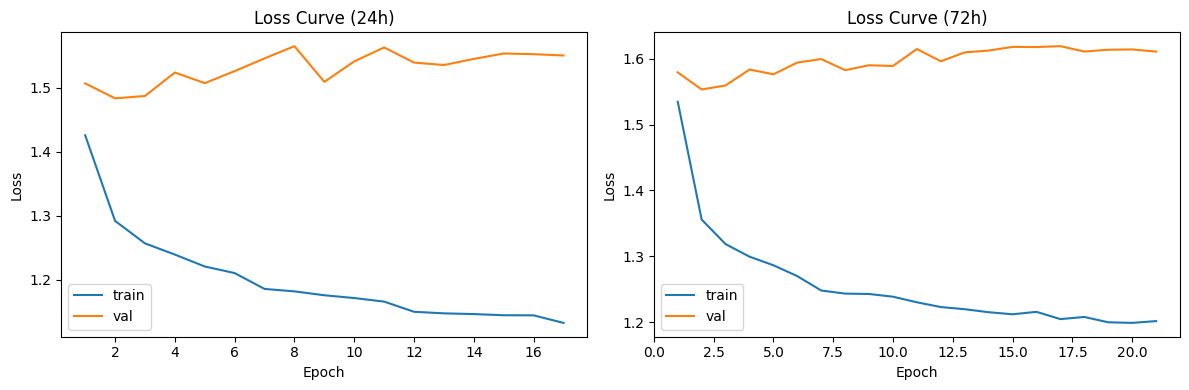

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, horizon in zip(axes, HORIZONS):
    hist_df = training_history[horizon]
    ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], label="val")
    ax.set_title(f"Loss Curve ({horizon})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
%pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Data quality audit for modeling splits
target_cols = [f"n_aftershocks_{h}" for h in HORIZONS]
numeric_feature_cols = [c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(train_df[c])]

def split_audit(df: pd.DataFrame, split_name: str) -> dict:
    row = {
        "split": split_name,
        "rows": len(df),
        "unique_trigger_ids": df["trigger_event_id"].nunique() if "trigger_event_id" in df.columns else np.nan,
        "duplicate_trigger_rows": int(df.duplicated(subset=["trigger_event_id"]).sum()) if "trigger_event_id" in df.columns else np.nan,
        "feature_missing_pct": float(df[FEATURE_COLS].isna().mean().mean() * 100),
        "feature_cols_gt30pct_missing": int((df[FEATURE_COLS].isna().mean() > 0.30).sum()),
    }
    for tcol in target_cols:
        if tcol in df.columns:
            y = df[tcol]
            row[f"{tcol}_missing_pct"] = float(y.isna().mean() * 100)
            row[f"{tcol}_negative_count"] = int((y < 0).sum(skipna=True))
            row[f"{tcol}_zero_pct"] = float((y.fillna(0) == 0).mean() * 100)
            row[f"{tcol}_p99"] = float(y.quantile(0.99))
            row[f"{tcol}_max"] = float(y.max())
            iqr = float((y.quantile(0.75) - y.quantile(0.25)))
            ub = float(y.quantile(0.75) + 3.0 * iqr)
            row[f"{tcol}_gt_upper_bound_3iqr"] = int((y > ub).sum(skipna=True))
    return row

audit_df = pd.DataFrame([
    split_audit(train_df, "train"),
    split_audit(val_df, "val"),
    split_audit(test_df, "test"),
])

print("=== Split-Level Data Audit ===")
print(audit_df.to_string(index=False))

# Top missing feature columns in train split
missing_train = (
    train_df[FEATURE_COLS].isna().mean().sort_values(ascending=False).rename("missing_frac")
    .reset_index()
    .rename(columns={"index": "feature"})
)
print("\n=== Top 20 Missing Features (Train) ===")
print(missing_train.head(20).to_string(index=False))

# Check for non-finite numeric values
def non_finite_count(df: pd.DataFrame, cols: list[str]) -> int:
    if not cols:
        return 0
    x = df[cols].to_numpy(dtype=np.float64, copy=True)
    return int((~np.isfinite(x)).sum())

print("\n=== Non-finite Numeric Values ===")
print(f"Train non-finite count: {non_finite_count(train_df, numeric_feature_cols)}")
print(f"Val non-finite count:   {non_finite_count(val_df, numeric_feature_cols)}")
print(f"Test non-finite count:  {non_finite_count(test_df, numeric_feature_cols)}")

# Compare train vs test feature median drift (robust quick signal)
drift_rows = []
for col in numeric_feature_cols:
    tr = train_df[col].dropna()
    te = test_df[col].dropna()
    if len(tr) == 0 or len(te) == 0:
        continue
    tr_med = float(tr.median())
    te_med = float(te.median())
    denom = abs(tr_med) + 1e-6
    rel_shift = abs(te_med - tr_med) / denom
    drift_rows.append({"feature": col, "train_median": tr_med, "test_median": te_med, "rel_shift": rel_shift})

drift_df = pd.DataFrame(drift_rows).sort_values("rel_shift", ascending=False)
print("\n=== Top 20 Median Shift Features (Train vs Test) ===")
print(drift_df.head(20).to_string(index=False))

=== Split-Level Data Audit ===
split  rows  unique_trigger_ids  duplicate_trigger_rows  feature_missing_pct  feature_cols_gt30pct_missing  n_aftershocks_24h_missing_pct  n_aftershocks_24h_negative_count  n_aftershocks_24h_zero_pct  n_aftershocks_24h_p99  n_aftershocks_24h_max  n_aftershocks_24h_gt_upper_bound_3iqr  n_aftershocks_72h_missing_pct  n_aftershocks_72h_negative_count  n_aftershocks_72h_zero_pct  n_aftershocks_72h_p99  n_aftershocks_72h_max  n_aftershocks_72h_gt_upper_bound_3iqr
train 23031               23031                       0            15.115876                             2                            0.0                                 0                   55.716209                  87.00                 1253.0                                   2847                            0.0                                 0                   49.646129                 140.00                 1643.0                                   2876
  val  1744                1744            

In [9]:
FEATURE_COLS = FULL_FEATURE_SET

DEFAULT_CFG = {
    "batch_size": 256,
    "epochs": 90,
    "lr": 8e-4,
    "weight_decay": 1e-4,
    "patience": 16,
    "lambda_cls": 1.0,
    "lambda_reg": 1.0,
    "hidden_dim": 192,
    "dropout": 0.22,
    "clip_grad": 1.0,
}

HORIZON_CONFIGS = {
    "24h": {
        "batch_size": 256,
        "epochs": 90,
        "lr": 8e-4,
        "weight_decay": 8e-5,
        "patience": 16,
        "lambda_cls": 1.0,
        "lambda_reg": 1.1,
        "hidden_dim": 192,
        "dropout": 0.18,
        "clip_grad": 1.0,
    },
    "72h": {
        "batch_size": 192,
        "epochs": 110,
        "lr": 5e-4,
        "weight_decay": 1.5e-4,
        "patience": 20,
        "lambda_cls": 0.95,
        "lambda_reg": 1.2,
        "hidden_dim": 256,
        "dropout": 0.25,
        "clip_grad": 1.0,
    },
}

LOG1P_FEATURES = [
    "prior_global_event_count_24h",
    "prior_global_event_count_7d",
]

WINSORIZE_CANDIDATES = [
    "prior_global_event_count_24h",
    "prior_global_event_count_7d",
    "gcmt_distance_km",
    "gcmt_time_diff_sec",
    "trigger_depth_km",
    "gcmt_depth_km",
]

# Updated: all_cleaning for 24h, missing_flags_only for 72h
HORIZON_CLEANING_SETUP = {
    "24h": {"use_missing_flags": True, "use_log1p": True, "use_winsor": True},
    "72h": {"use_missing_flags": True, "use_log1p": False, "use_winsor": False},
}

TARGET_CAPS = {
    "24h": 300.0,
    "72h": 500.0,
}

In [10]:
# Focused 24h refinement sweep
REFINE_24H_CANDIDATES = [
    {
        "name": "c1_winsor_less_cls",
        "train": {"batch_size": 256, "epochs": 90, "lr": 8e-4, "weight_decay": 8e-5, "patience": 16, "lambda_cls": 1.0, "lambda_reg": 1.1, "hidden_dim": 192, "dropout": 0.18, "clip_grad": 1.0},
        "clean": {"use_missing_flags": False, "use_log1p": False, "use_winsor": True},
    },
    {
        "name": "c2_winsor_bigger_model",
        "train": {"batch_size": 256, "epochs": 100, "lr": 7e-4, "weight_decay": 8e-5, "patience": 20, "lambda_cls": 1.0, "lambda_reg": 1.1, "hidden_dim": 256, "dropout": 0.15, "clip_grad": 1.0},
        "clean": {"use_missing_flags": False, "use_log1p": False, "use_winsor": True},
    },
    {
        "name": "c3_no_clean_baseline_like",
        "train": {"batch_size": 256, "epochs": 90, "lr": 9e-4, "weight_decay": 8e-5, "patience": 16, "lambda_cls": 1.0, "lambda_reg": 1.0, "hidden_dim": 128, "dropout": 0.2, "clip_grad": 1.0},
        "clean": {"use_missing_flags": False, "use_log1p": False, "use_winsor": False},
    },
    {
        "name": "c4_winsor_reg_heavier",
        "train": {"batch_size": 256, "epochs": 100, "lr": 7e-4, "weight_decay": 1e-4, "patience": 20, "lambda_cls": 0.9, "lambda_reg": 1.2, "hidden_dim": 256, "dropout": 0.15, "clip_grad": 1.0},
        "clean": {"use_missing_flags": False, "use_log1p": False, "use_winsor": True},
    },
]

def run_24h_candidate(candidate: dict, seed: int = 42) -> dict:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    cfg = candidate["train"]
    clean_cfg = candidate["clean"]
    target_col = "n_aftershocks_24h"

    train_keep, X_train_df, y_train_s = prepare_arrays(train_df, FEATURE_COLS, target_col)
    val_keep, X_val_df, y_val_s = prepare_arrays(val_df, FEATURE_COLS, target_col)
    test_keep, X_test_df, y_test_s = prepare_arrays(test_df, FEATURE_COLS, target_col)

    Xt = X_train_df.copy()
    Xv = X_val_df.copy()
    Xs = X_test_df.copy()
    feat_cols = FEATURE_COLS.copy()

    if clean_cfg["use_missing_flags"]:
        for col in GCMT_FEATURES:
            if col in Xt.columns and Xt[col].isna().mean() > 0.05:
                flag = f"{col}__is_missing"
                Xt[flag] = Xt[col].isna().astype(np.float32)
                Xv[flag] = Xv[col].isna().astype(np.float32)
                Xs[flag] = Xs[col].isna().astype(np.float32)
                feat_cols.append(flag)

    if clean_cfg["use_log1p"]:
        for col in LOG1P_FEATURES:
            if col in Xt.columns:
                Xt[col] = np.log1p(Xt[col].clip(lower=0))
                Xv[col] = np.log1p(Xv[col].clip(lower=0))
                Xs[col] = np.log1p(Xs[col].clip(lower=0))

    if clean_cfg["use_winsor"]:
        for col in WINSORIZE_CANDIDATES:
            if col in Xt.columns:
                lo = float(Xt[col].quantile(0.005))
                hi = float(Xt[col].quantile(0.995))
                if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
                    Xt[col] = Xt[col].clip(lower=lo, upper=hi)
                    Xv[col] = Xv[col].clip(lower=lo, upper=hi)
                    Xs[col] = Xs[col].clip(lower=lo, upper=hi)

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(Xt[feat_cols])).astype(np.float32)
    X_val = scaler.transform(imputer.transform(Xv[feat_cols])).astype(np.float32)
    X_test = scaler.transform(imputer.transform(Xs[feat_cols])).astype(np.float32)

    y_train = y_train_s.to_numpy(dtype=np.float32)
    y_val = y_val_s.to_numpy(dtype=np.float32)
    y_test = y_test_s.to_numpy(dtype=np.float32)

    y_train_nonzero = (y_train > 0).astype(np.float32)
    y_val_nonzero = (y_val > 0).astype(np.float32)
    y_train_log = np.log1p(y_train).astype(np.float32)
    y_val_log = np.log1p(y_val).astype(np.float32)

    train_ds = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train_nonzero),
        torch.from_numpy(y_train_log),
        torch.from_numpy(y_train),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val),
        torch.from_numpy(y_val_nonzero),
        torch.from_numpy(y_val_log),
        torch.from_numpy(y_val),
    )
    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False)

    model = TwoHeadNet(n_features=X_train.shape[1], hidden_dim=cfg["hidden_dim"], dropout=cfg["dropout"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"] )

    n_pos = max(1.0, float(y_train_nonzero.sum()))
    n_neg = max(1.0, float(len(y_train_nonzero) - y_train_nonzero.sum()))
    pos_weight = torch.tensor([n_neg / n_pos], device=device, dtype=torch.float32)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    reg_loss_fn = nn.SmoothL1Loss(beta=0.35)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4, threshold=1e-4, min_lr=1e-6
    )

    best_state = None
    best_val_mae = float("inf")
    best_epoch = 0
    patience_ctr = 0

    def predict_expected_count(X_np: np.ndarray) -> np.ndarray:
        xb = torch.from_numpy(X_np).to(device)
        with torch.no_grad():
            logit_nonzero, log_count = model(xb)
            p_nonzero = torch.sigmoid(logit_nonzero)
            cond_count = torch.expm1(log_count)
            pred = p_nonzero * cond_count
        return pred.detach().cpu().numpy().astype(np.float64)

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        for xb, yb_nonzero, yb_log, yb_raw in train_loader:
            xb = xb.to(device)
            yb_nonzero = yb_nonzero.to(device)
            yb_log = yb_log.to(device)
            yb_raw = yb_raw.to(device)

            optimizer.zero_grad()
            logit_nonzero, log_count = model(xb)
            loss_cls = bce(logit_nonzero, yb_nonzero)
            mask = yb_raw > 0
            if mask.any():
                loss_reg = reg_loss_fn(log_count[mask], yb_log[mask])
            else:
                loss_reg = torch.tensor(0.0, device=device)
            loss = cfg["lambda_cls"] * loss_cls + cfg["lambda_reg"] * loss_reg
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["clip_grad"])
            optimizer.step()

        model.eval()
        val_pred_epoch = predict_expected_count(X_val)
        val_mae_epoch = mean_absolute_error(y_val, val_pred_epoch)
        scheduler.step(val_mae_epoch)

        if val_mae_epoch < best_val_mae:
            best_val_mae = val_mae_epoch
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= cfg["patience"]:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    preds_test = predict_expected_count(X_test)

    return {
        "candidate": candidate["name"],
        "best_epoch": int(best_epoch),
        "val_mae": round(float(best_val_mae), 4),
        "test_mae": round(float(mean_absolute_error(y_test, preds_test)), 4),
        "test_rmse": round(float(np.sqrt(mean_squared_error(y_test, preds_test))), 4),
    }

refine_24h_rows = []
for cand in REFINE_24H_CANDIDATES:
    print(f"Running {cand['name']}...")
    out = run_24h_candidate(cand, seed=42)
    refine_24h_rows.append(out)
    print(
        f"  best_epoch={out['best_epoch']} | val_mae={out['val_mae']:.4f} "
        f"| test_mae={out['test_mae']:.4f} | test_rmse={out['test_rmse']:.4f}"
    )

refine_24h_df = pd.DataFrame(refine_24h_rows).sort_values(["test_mae", "test_rmse"]).reset_index(drop=True)
print("\n=== 24h Refinement Results (sorted by test_mae) ===")
print(refine_24h_df.to_string(index=False))
print("\nBest 24h candidate:")
print(refine_24h_df.head(1).to_string(index=False))

Running c1_winsor_less_cls...
  best_epoch=3 | val_mae=12.8639 | test_mae=8.9146 | test_rmse=27.5433
Running c2_winsor_bigger_model...
  best_epoch=2 | val_mae=12.9631 | test_mae=8.9304 | test_rmse=27.1751
Running c3_no_clean_baseline_like...
  best_epoch=1 | val_mae=12.7670 | test_mae=8.8453 | test_rmse=27.0558
Running c4_winsor_reg_heavier...
  best_epoch=2 | val_mae=12.9680 | test_mae=8.9370 | test_rmse=27.1926

=== 24h Refinement Results (sorted by test_mae) ===
                candidate  best_epoch  val_mae  test_mae  test_rmse
c3_no_clean_baseline_like           1  12.7670    8.8453    27.0558
       c1_winsor_less_cls           3  12.8639    8.9146    27.5433
   c2_winsor_bigger_model           2  12.9631    8.9304    27.1751
    c4_winsor_reg_heavier           2  12.9680    8.9370    27.1926

Best 24h candidate:
                candidate  best_epoch  val_mae  test_mae  test_rmse
c3_no_clean_baseline_like           1   12.767    8.8453    27.0558


In [11]:
# Retune after dataset expansion with fit diagnostics
splits_eng = {name: engineer_features(df) for name, df in splits.items()}
train_df = splits_eng["train"].copy()
val_df   = splits_eng["val"].copy()
test_df  = splits_eng["test"].copy()
print(f"Expanded dataset sizes -> Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

RETUNE_EXPANDED = {
    "24h": [
        {"name": "24h_small_no_clean", "cfg": {"batch_size": 256, "epochs": 90, "lr": 9e-4, "weight_decay": 8e-5, "patience": 16, "lambda_cls": 1.0, "lambda_reg": 1.0, "hidden_dim": 128, "dropout": 0.20, "clip_grad": 1.0}, "clean": {"use_missing_flags": False, "use_log1p": False, "use_winsor": False}},
        {"name": "24h_mid_winsor", "cfg": {"batch_size": 256, "epochs": 90, "lr": 8e-4, "weight_decay": 8e-5, "patience": 16, "lambda_cls": 1.0, "lambda_reg": 1.1, "hidden_dim": 192, "dropout": 0.18, "clip_grad": 1.0}, "clean": {"use_missing_flags": False, "use_log1p": False, "use_winsor": True}},
        {"name": "24h_high_capacity", "cfg": {"batch_size": 256, "epochs": 100, "lr": 7e-4, "weight_decay": 1e-4, "patience": 18, "lambda_cls": 0.95, "lambda_reg": 1.15, "hidden_dim": 256, "dropout": 0.15, "clip_grad": 1.0}, "clean": {"use_missing_flags": False, "use_log1p": False, "use_winsor": True}},
    ],
    "72h": [
        {"name": "72h_log_balanced", "cfg": {"batch_size": 192, "epochs": 100, "lr": 6e-4, "weight_decay": 1.2e-4, "patience": 18, "lambda_cls": 1.0, "lambda_reg": 1.1, "hidden_dim": 256, "dropout": 0.25, "clip_grad": 1.0}, "clean": {"use_missing_flags": False, "use_log1p": True, "use_winsor": False}},
        {"name": "72h_log_reg_stronger", "cfg": {"batch_size": 192, "epochs": 110, "lr": 5e-4, "weight_decay": 1.5e-4, "patience": 20, "lambda_cls": 0.95, "lambda_reg": 1.2, "hidden_dim": 256, "dropout": 0.25, "clip_grad": 1.0}, "clean": {"use_missing_flags": False, "use_log1p": True, "use_winsor": False}},
        {"name": "72h_wider_log", "cfg": {"batch_size": 192, "epochs": 110, "lr": 5e-4, "weight_decay": 1.5e-4, "patience": 20, "lambda_cls": 1.0, "lambda_reg": 1.15, "hidden_dim": 320, "dropout": 0.22, "clip_grad": 1.0}, "clean": {"use_missing_flags": False, "use_log1p": True, "use_winsor": False}},
    ],
}

def run_retune_candidate(horizon: str, candidate: dict, seed: int = 42) -> dict:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    cfg = candidate["cfg"]
    clean_cfg = candidate["clean"]
    target_col = f"n_aftershocks_{horizon}"

    train_keep, X_train_df, y_train_s = prepare_arrays(train_df, FEATURE_COLS, target_col)
    val_keep, X_val_df, y_val_s = prepare_arrays(val_df, FEATURE_COLS, target_col)
    test_keep, X_test_df, y_test_s = prepare_arrays(test_df, FEATURE_COLS, target_col)

    Xt = X_train_df.copy()
    Xv = X_val_df.copy()
    Xs = X_test_df.copy()
    feat_cols = FEATURE_COLS.copy()

    if clean_cfg["use_missing_flags"]:
        for col in GCMT_FEATURES:
            if col in Xt.columns and Xt[col].isna().mean() > 0.05:
                flag = f"{col}__is_missing"
                Xt[flag] = Xt[col].isna().astype(np.float32)
                Xv[flag] = Xv[col].isna().astype(np.float32)
                Xs[flag] = Xs[col].isna().astype(np.float32)
                feat_cols.append(flag)

    if clean_cfg["use_log1p"]:
        for col in LOG1P_FEATURES:
            if col in Xt.columns:
                Xt[col] = np.log1p(Xt[col].clip(lower=0))
                Xv[col] = np.log1p(Xv[col].clip(lower=0))
                Xs[col] = np.log1p(Xs[col].clip(lower=0))

    if clean_cfg["use_winsor"]:
        for col in WINSORIZE_CANDIDATES:
            if col in Xt.columns:
                lo = float(Xt[col].quantile(0.005))
                hi = float(Xt[col].quantile(0.995))
                if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
                    Xt[col] = Xt[col].clip(lower=lo, upper=hi)
                    Xv[col] = Xv[col].clip(lower=lo, upper=hi)
                    Xs[col] = Xs[col].clip(lower=lo, upper=hi)

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(Xt[feat_cols])).astype(np.float32)
    X_val = scaler.transform(imputer.transform(Xv[feat_cols])).astype(np.float32)
    X_test = scaler.transform(imputer.transform(Xs[feat_cols])).astype(np.float32)

    y_train = y_train_s.to_numpy(dtype=np.float32)
    y_val = y_val_s.to_numpy(dtype=np.float32)
    y_test = y_test_s.to_numpy(dtype=np.float32)
    y_train_nonzero = (y_train > 0).astype(np.float32)
    y_train_log = np.log1p(y_train).astype(np.float32)
    y_val_nonzero = (y_val > 0).astype(np.float32)
    y_val_log = np.log1p(y_val).astype(np.float32)

    train_ds = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train_nonzero),
        torch.from_numpy(y_train_log),
        torch.from_numpy(y_train),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val),
        torch.from_numpy(y_val_nonzero),
        torch.from_numpy(y_val_log),
        torch.from_numpy(y_val),
    )

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False)

    model = TwoHeadNet(
        n_features=X_train.shape[1],
        hidden_dim=cfg["hidden_dim"],
        dropout=cfg["dropout"],
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"] )

    n_pos = max(1.0, float(y_train_nonzero.sum()))
    n_neg = max(1.0, float(len(y_train_nonzero) - y_train_nonzero.sum()))
    pos_weight = torch.tensor([n_neg / n_pos], device=device, dtype=torch.float32)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    reg_loss_fn = nn.SmoothL1Loss(beta=0.35)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4, threshold=1e-4, min_lr=1e-6
    )

    best_state = None
    best_val_mae = float("inf")
    best_epoch = 0
    patience_ctr = 0

    def predict_expected_count(X_np: np.ndarray) -> np.ndarray:
        xb = torch.from_numpy(X_np).to(device)
        with torch.no_grad():
            logit_nonzero, log_count = model(xb)
            p_nonzero = torch.sigmoid(logit_nonzero)
            cond_count = torch.expm1(log_count)
            pred = p_nonzero * cond_count
        return pred.detach().cpu().numpy().astype(np.float64)

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        for xb, yb_nonzero, yb_log, yb_raw in train_loader:
            xb = xb.to(device)
            yb_nonzero = yb_nonzero.to(device)
            yb_log = yb_log.to(device)
            yb_raw = yb_raw.to(device)

            optimizer.zero_grad()
            logit_nonzero, log_count = model(xb)
            loss_cls = bce(logit_nonzero, yb_nonzero)
            mask = yb_raw > 0
            if mask.any():
                loss_reg = reg_loss_fn(log_count[mask], yb_log[mask])
            else:
                loss_reg = torch.tensor(0.0, device=device)
            loss = cfg["lambda_cls"] * loss_cls + cfg["lambda_reg"] * loss_reg
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["clip_grad"])
            optimizer.step()

        model.eval()
        val_pred = predict_expected_count(X_val)
        val_mae = mean_absolute_error(y_val, val_pred)
        scheduler.step(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= cfg["patience"]:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()

    pred_train = predict_expected_count(X_train)
    pred_val = predict_expected_count(X_val)
    pred_test = predict_expected_count(X_test)

    train_mae = mean_absolute_error(y_train, pred_train)
    val_mae = mean_absolute_error(y_val, pred_val)
    test_mae = mean_absolute_error(y_test, pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    gap = val_mae - train_mae

    fit_tag = "balanced"
    if gap > 1.0:
        fit_tag = "overfitting"
    elif gap < -0.5:
        fit_tag = "underfitting_or_val_easier"

    return {
        "horizon": horizon,
        "candidate": candidate["name"],
        "best_epoch": int(best_epoch),
        "train_mae": round(float(train_mae), 4),
        "val_mae": round(float(val_mae), 4),
        "gap_val_minus_train": round(float(gap), 4),
        "fit_diagnosis": fit_tag,
        "test_mae": round(float(test_mae), 4),
        "test_rmse": round(float(test_rmse), 4),
    }

retune_rows = []
for horizon in HORIZONS:
    print(f"\n--- Retuning {horizon} on expanded dataset ---")
    for cand in RETUNE_EXPANDED[horizon]:
        out = run_retune_candidate(horizon, cand, seed=42)
        retune_rows.append(out)
        print(
            f"{out['candidate']:<24} | train_mae={out['train_mae']:.4f} | val_mae={out['val_mae']:.4f} "
            f"| gap={out['gap_val_minus_train']:.4f} | {out['fit_diagnosis']} "
            f"| test_mae={out['test_mae']:.4f} | test_rmse={out['test_rmse']:.4f}"
        )

retune_df = pd.DataFrame(retune_rows).sort_values(["horizon", "val_mae", "test_mae"]).reset_index(drop=True)
print("\n=== Expanded-Data Retune Results (sorted by horizon/val_mae) ===")
print(retune_df.to_string(index=False))

best_retune = retune_df.groupby("horizon", as_index=False).head(1)
print("\n=== Best Candidate Per Horizon (by val_mae) ===")
print(best_retune.to_string(index=False))

Expanded dataset sizes -> Train: 23,031 | Val: 1,744 | Test: 3,513

--- Retuning 24h on expanded dataset ---
24h_small_no_clean       | train_mae=6.0533 | val_mae=12.7670 | gap=6.7137 | overfitting | test_mae=8.8453 | test_rmse=27.0558
24h_mid_winsor           | train_mae=5.8253 | val_mae=12.8639 | gap=7.0386 | overfitting | test_mae=8.9146 | test_rmse=27.5433
24h_high_capacity        | train_mae=5.9098 | val_mae=12.9660 | gap=7.0561 | overfitting | test_mae=8.9344 | test_rmse=27.1856

--- Retuning 72h on expanded dataset ---
72h_log_balanced         | train_mae=8.9338 | val_mae=19.7922 | gap=10.8584 | overfitting | test_mae=13.4550 | test_rmse=41.5613
72h_log_reg_stronger     | train_mae=8.9753 | val_mae=19.7849 | gap=10.8096 | overfitting | test_mae=13.4205 | test_rmse=41.4550
72h_wider_log            | train_mae=9.6148 | val_mae=19.6140 | gap=9.9992 | overfitting | test_mae=13.5639 | test_rmse=43.5638

=== Expanded-Data Retune Results (sorted by horizon/val_mae) ===
horizon         

In [12]:
# Split drift report after dataset expansion
from scipy.stats import ks_2samp

def robust_shift(a: pd.Series, b: pd.Series) -> float:
    a = a.dropna()
    b = b.dropna()
    if len(a) == 0 or len(b) == 0:
        return np.nan
    am = float(a.median())
    bm = float(b.median())
    scale = float(np.median(np.abs(a - am))) + 1e-6
    return abs(bm - am) / scale

num_cols = [c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(train_df[c])]
drift_rows = []
for col in num_cols:
    tr = train_df[col]
    va = val_df[col]
    te = test_df[col]
    if tr.dropna().empty or va.dropna().empty or te.dropna().empty:
        continue
    ks_tv = ks_2samp(tr.dropna(), va.dropna(), alternative="two-sided", method="asymp").statistic
    ks_tt = ks_2samp(tr.dropna(), te.dropna(), alternative="two-sided", method="asymp").statistic
    drift_rows.append({
        "feature": col,
        "train_missing": float(tr.isna().mean()),
        "val_missing": float(va.isna().mean()),
        "test_missing": float(te.isna().mean()),
        "ks_train_val": float(ks_tv),
        "ks_train_test": float(ks_tt),
        "robust_shift_train_val": float(robust_shift(tr, va)),
        "robust_shift_train_test": float(robust_shift(tr, te)),
    })

drift_report_df = pd.DataFrame(drift_rows)
drift_report_df["drift_score"] = (
    0.4 * drift_report_df["ks_train_val"]
    + 0.4 * drift_report_df["ks_train_test"]
    + 0.1 * drift_report_df["robust_shift_train_val"].fillna(0)
    + 0.1 * drift_report_df["robust_shift_train_test"].fillna(0)
    + 0.5 * (drift_report_df["test_missing"] - drift_report_df["train_missing"]).abs()
    + 0.5 * (drift_report_df["val_missing"] - drift_report_df["train_missing"]).abs()
 )

drift_report_df = drift_report_df.sort_values("drift_score", ascending=False).reset_index(drop=True)
print("=== Top 25 Feature Drift Signals (train vs val/test) ===")
print(
    drift_report_df[[
        "feature",
        "drift_score",
        "ks_train_val",
        "ks_train_test",
        "robust_shift_train_val",
        "robust_shift_train_test",
        "train_missing",
        "val_missing",
        "test_missing",
    ]].head(25).to_string(index=False)
 )

# Target drift summary
target_drift = []
for h in HORIZONS:
    t = f"n_aftershocks_{h}"
    tr = train_df[t].dropna()
    va = val_df[t].dropna()
    te = test_df[t].dropna()
    target_drift.append({
        "target": t,
        "train_zero_pct": float((tr == 0).mean()),
        "val_zero_pct": float((va == 0).mean()),
        "test_zero_pct": float((te == 0).mean()),
        "train_p99": float(tr.quantile(0.99)),
        "val_p99": float(va.quantile(0.99)),
        "test_p99": float(te.quantile(0.99)),
        "ks_train_val": float(ks_2samp(tr, va, method="asymp").statistic),
        "ks_train_test": float(ks_2samp(tr, te, method="asymp").statistic),
    })

target_drift_df = pd.DataFrame(target_drift)
print("\n=== Target Drift Summary ===")
print(target_drift_df.to_string(index=False))

=== Top 25 Feature Drift Signals (train vs val/test) ===
                           feature   drift_score  ks_train_val  ks_train_test  robust_shift_train_val  robust_shift_train_test  train_missing  val_missing  test_missing
                      ring_of_fire 100000.022288      0.030802       0.024918                0.000000             1.000000e+06       0.000000     0.000000      0.000000
      prior_global_event_count_24h      1.295242      1.000000       1.000000                2.251928             2.700497e+00       0.000000     0.000000      0.000000
       prior_global_event_count_7d      1.295242      1.000000       1.000000                2.251928             2.700497e+00       0.000000     0.000000      0.000000
                     log_prior_24h      1.091722      1.000000       1.000000                1.373383             1.543840e+00       0.000000     0.000000      0.000000
                      log_prior_7d      1.091722      1.000000       1.000000                1.373

=== Per-Year Aftershock Statistics ===
 trigger_year  n_events  mean_24h  mean_72h  median_24h  p99_24h  p99_72h  zero_pct_24h
         2010      2293  9.846925 16.746620         0.0   190.00   313.24     55.822067
         2011      2628  8.340183 16.011035         0.0    75.00   143.19     50.152207
         2012      1652  3.117433  4.696731         0.0    47.49    66.00     60.108959
         2013      1554  7.922136 13.438867         0.0    88.47   142.00     54.504505
         2014      1680  7.261310 10.656548         0.0    91.21   124.00     53.333333
         2015      1532  6.291123  9.334856         0.0   100.69   145.69     56.266319
         2016      1664  6.091346  9.053486         0.0    73.00   107.37     55.468750
         2017      1486  4.606999  7.010094         0.0    71.00   111.15     62.045760
         2018      1721  7.185938 11.072051         0.0   124.80   186.40     56.478791
         2019      1597  6.394490  9.595492         0.0    55.16    74.12     59.

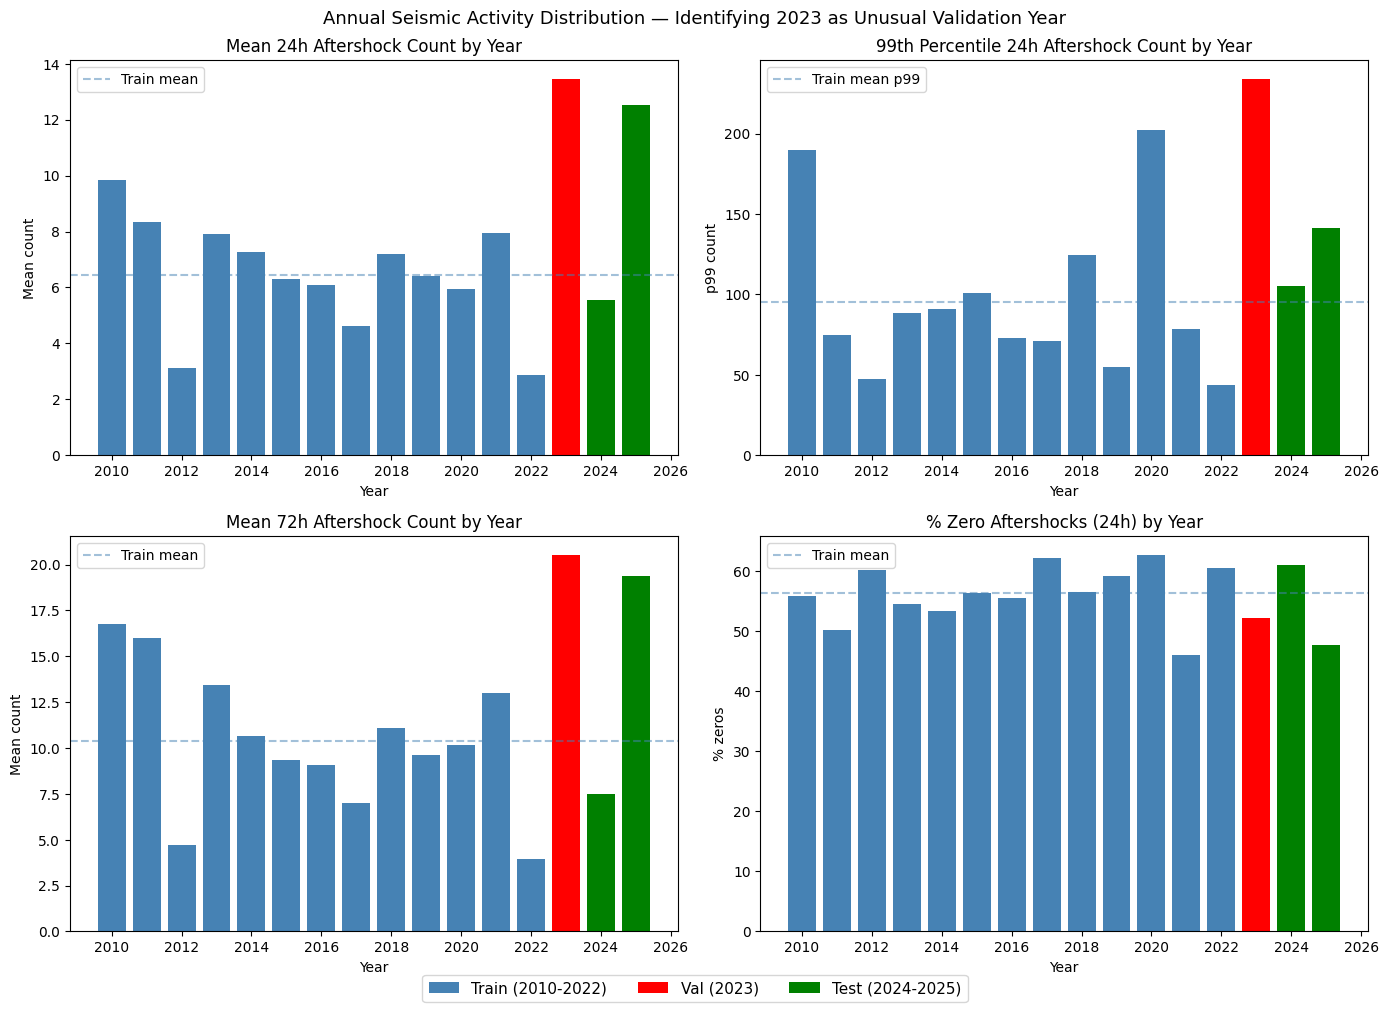

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# combine all splits for year-level analysis
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
full_df["trigger_year"] = pd.to_datetime(full_df["trigger_time"], utc=True, errors="coerce").dt.year

# compute per-year stats
yearly_stats = full_df.groupby("trigger_year").agg(
    n_events=("n_aftershocks_24h", "count"),
    mean_24h=("n_aftershocks_24h", "mean"),
    mean_72h=("n_aftershocks_72h", "mean"),
    median_24h=("n_aftershocks_24h", "median"),
    p99_24h=("n_aftershocks_24h", lambda x: np.percentile(x.dropna(), 99)),
    p99_72h=("n_aftershocks_72h", lambda x: np.percentile(x.dropna(), 99)),
    zero_pct_24h=("n_aftershocks_24h", lambda x: (x == 0).mean() * 100),
).reset_index()

print("=== Per-Year Aftershock Statistics ===")
print(yearly_stats.to_string(index=False))

# plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# color code by split
def year_color(year):
    if year <= 2022:
        return "steelblue"
    elif year == 2023:
        return "red"
    else:
        return "green"

colors = [year_color(y) for y in yearly_stats["trigger_year"]]

# mean aftershock count per year
axes[0,0].bar(yearly_stats["trigger_year"], yearly_stats["mean_24h"], color=colors)
axes[0,0].set_title("Mean 24h Aftershock Count by Year")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Mean count")
axes[0,0].axhline(yearly_stats[yearly_stats["trigger_year"] <= 2022]["mean_24h"].mean(), 
                   color="steelblue", linestyle="--", alpha=0.5, label="Train mean")
axes[0,0].legend()

# p99 per year
axes[0,1].bar(yearly_stats["trigger_year"], yearly_stats["p99_24h"], color=colors)
axes[0,1].set_title("99th Percentile 24h Aftershock Count by Year")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("p99 count")
axes[0,1].axhline(yearly_stats[yearly_stats["trigger_year"] <= 2022]["p99_24h"].mean(),
                   color="steelblue", linestyle="--", alpha=0.5, label="Train mean p99")
axes[0,1].legend()

# mean 72h
axes[1,0].bar(yearly_stats["trigger_year"], yearly_stats["mean_72h"], color=colors)
axes[1,0].set_title("Mean 72h Aftershock Count by Year")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Mean count")
axes[1,0].axhline(yearly_stats[yearly_stats["trigger_year"] <= 2022]["mean_72h"].mean(),
                   color="steelblue", linestyle="--", alpha=0.5, label="Train mean")
axes[1,0].legend()

# zero pct per year
axes[1,1].bar(yearly_stats["trigger_year"], yearly_stats["zero_pct_24h"], color=colors)
axes[1,1].set_title("% Zero Aftershocks (24h) by Year")
axes[1,1].set_xlabel("Year")
axes[1,1].set_ylabel("% zeros")
axes[1,1].axhline(yearly_stats[yearly_stats["trigger_year"] <= 2022]["zero_pct_24h"].mean(),
                   color="steelblue", linestyle="--", alpha=0.5, label="Train mean")
axes[1,1].legend()

# add legend for split colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Train (2010-2022)"),
    Patch(facecolor="red", label="Val (2023)"),
    Patch(facecolor="green", label="Test (2024-2025)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=11, 
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Annual Seismic Activity Distribution — Identifying 2023 as Unusual Validation Year", 
             fontsize=13)
plt.tight_layout()
plt.show()